In [128]:
# ── Imports ────────────────────────────────────────────────────────────────────
import pickle
import pandas as pd
import numpy as np
from rdkit import Chem
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ══════════════════════════════════════════════════════════════════════════════
# USER CONFIGURATION — edit these four variables only
# ══════════════════════════════════════════════════════════════════════════════
MEL_ICM_INCHIKEY = "ZDVYFDNVNNMFHN_VNQOBHDRSA_N"   # ICM InChIKey of the MEL (hyphens)

ICM_SCREEN_REPLACEMENT_SDF = (
    "/home/wenjinl/Desktop/SmartEnumeration/PocketInformedSyntonSelection"
    "/ICMScreenReplacementGroups/PilotStudy/Benchmark_5TH2A_7WC6"
    "/ICMScreenReplacementSyntonRanking/5TH2A_7WC6_Rank3_ZDVYF_ICM_Screen_Replacement_Results.sdf"
)

ENUMERATED_PRODUCTS_PKL = (
    "/home/wenjinl/Desktop/SmartEnumeration/PocketInformedSyntonSelection"
    "/ICMScreenReplacementGroups/PilotStudy/Benchmark_5TH2A_7WC6/EnumeratedProducts"
    "/Rank3_ICMInChiKey_ZDVYFDNVNNMFHN_VNQOBHDRSA_N_OpenVSInChiKey_ANFZKEURAJZAFG-FRZXBFBESA-N_enumerated_products.pkl"
)

ICM_FULL_LIGANDS_DOCKED_CSV = (
    "/home/wenjinl/Desktop/SmartEnumeration/PocketInformedSyntonSelection"
    "/ICMScreenReplacementGroups/PilotStudy/Benchmark_5TH2A_7WC6/FullLigandICM393Docked"
    "/Dock_7WC6_Fix_Rank2_ANFZKEURAJZAFG-FRZXBFBESA-N_30470_instructions_products1.csv"
)

TOP_N_ENRICHMENT = 200    # "best batch" size for enrichment analysis
# ══════════════════════════════════════════════════════════════════════════════


# ── 1. Load ICM Screen Replacement SDF → df_proxy ─────────────────────────────
suppl = Chem.SDMolSupplier(ICM_SCREEN_REPLACEMENT_SDF, removeHs=False, sanitize=False)
proxy_records = []
for mol in suppl:
    if mol is None:
        continue
    props = mol.GetPropsAsDict()
    props["_Name"] = mol.GetProp("_Name") if mol.HasProp("_Name") else None
    proxy_records.append(props)
df_proxy = pd.DataFrame(proxy_records)
print(f"[Proxy SDF]  {len(df_proxy)} synthons loaded")
print(f"  Columns: {list(df_proxy.columns)}")

[17:09:49] ERROR: Cannot convert ' -/3' to int on line 167413
[17:09:49] ERROR: moving to the beginning of the next molecule
[17:09:49] ERROR: Cannot convert ' -/4' to int on line 1161584
[17:09:49] ERROR: moving to the beginning of the next molecule
[17:09:49] ERROR: Cannot convert ' -/4' to int on line 1704692
[17:09:49] ERROR: moving to the beginning of the next molecule
[17:09:50] ERROR: Cannot convert ' -/4' to int on line 2801276
[17:09:50] ERROR: moving to the beginning of the next molecule
[17:09:50] ERROR: Cannot convert ' -/4' to int on line 3986231
[17:09:50] ERROR: moving to the beginning of the next molecule
[17:09:50] ERROR: Cannot convert ' -/4' to int on line 4122385
[17:09:50] ERROR: moving to the beginning of the next molecule
[17:09:50] ERROR: Cannot convert ' -/4' to int on line 4535027
[17:09:50] ERROR: moving to the beginning of the next molecule
[17:09:50] ERROR: Cannot convert ' -/4' to int on line 4824870
[17:09:50] ERROR: moving to the beginning of the next mo

[Proxy SDF]  10470 synthons loaded
  Columns: ['L', 'group', 'SubstScore', 'RTCNN_Score', 'DockScore', 'VlsScore', 'Strain', 'CoreRmsd', 'SCORE', 'KR', 'full_synthon_id', 'InchiKey', 'IsotopeIndicator', 'partial_charge', 'O', 'MolLogP', 'MolLogS', 'MoldHf', 'MolPSA', 'MolVolume', '_Name']


In [129]:
# Print first non-null value for each column in df_proxy
# The IsotopeIndicator trailing 1 is just ICM internally tagging the attachment point atom — the same atom your M  APO line marks. 
# It's not a chemical isotope, it's ICM saying "this is where the synthon connects to the scaffold." Your preprocessing is clean and working correctly.
for col in df_proxy.columns:
    first_val = df_proxy[col].dropna().iloc[1] if df_proxy[col].dropna().shape[0] > 0 else "ALL NULL"
    print(f"{col:25s} : {first_val}")

L                         : 0
group                     : [H]C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])OC(N1C([H])([H])[C@]2([H])C([H])([H])[C@]([H])(C1([H])[H])[N*]2)=O|8.68,7.77,9.34,7.11,10.00,6.45,10.00,7.77,8.35,6.12,9.34,5.13,9.74,4.29,10.69,5.49,8.58,4.60,7.36,7.11,8.98,8.46,6.01,6.75,7.60,8.01,7.36,5.13,7.72,3.78,6.73,2.79,5.38,3.15,5.78,4.00,4.62,3.69,4.39,2.16,3.49,2.40,6.02,2.07,6.95,2.09,6.03,3.01,6.11,0.45,6.35,-0.45,7.10,1.44,7.94,1.83,7.63,0.67,4.75,0.81,9.08,3.42
SubstScore                : -34.944984
RTCNN_Score               : -26.92773
DockScore                 : -1.294855
VlsScore                  : 0.0
Strain                    : -1.294855
CoreRmsd                  : 0.740336
SCORE                     : ( [9] 0, -1.29486, 0, 0, 0, 0, 0, 0, -26.9277 )
KR                        : 74
full_synthon_id           : s23409006
InchiKey                  : MHWWAAJLPXXEDK-OYPXTMMTSA-N
IsotopeIndicator          : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [130]:
# ── 2. Load enumerated products PKL → df_enum bridge ──────────────────────────
with open(ENUMERATED_PRODUCTS_PKL, "rb") as f:
    inchi_list, rdmol_list = pickle.load(f)

# ── Identify the MEL InChIKey by finding the part shared across all entries ───
# Each full_synthon_id = reactionID_____part1_____part2
# One part is always the MEL (constant), the other is the synthon (varies)
from collections import Counter

part_counter = Counter()
for mol_bin in rdmol_list:
    mol = Chem.Mol(mol_bin)
    full_id = mol.GetProp("full_synthon_id") if mol.HasProp("full_synthon_id") else ""
    parts = full_id.split("_____")
    for part in parts[1:]:
        if not part.startswith("sssss"):
            part_counter[part] += 1

# The MEL is the part that appears in (nearly) every entry
n_total = len(rdmol_list)
mel_openvs_inchikey = part_counter.most_common(1)[0][0]
mel_frequency       = part_counter.most_common(1)[0][1]

print(f"Total enumerated products : {n_total}")
print(f"Detected MEL OpenVS InChIKey : {mel_openvs_inchikey}")
print(f"  appears in {mel_frequency}/{n_total} entries ({100*mel_frequency/n_total:.1f}%)")
print(f"  (provided MEL_ICM_INCHIKEY for reference : {MEL_ICM_INCHIKEY})")


# ── Build synthon → full-ligand mapping using detected MEL to exclude ─────────
def parse_enum_record(inchikey, mol_bin, mel_openvs_ik):
    """Extract synthon and full-ligand InChIKeys from one enumerated product.
    
    full_synthon_id format: reactionID_____part1_____part2
    One of part1/part2 is the MEL (excluded), the other is the synthon (kept).
    The full-ligand InChIKey comes directly from inchi_list (the product identity).
    """
    mol    = Chem.Mol(mol_bin)
    full_id = mol.GetProp("full_synthon_id") if mol.HasProp("full_synthon_id") else ""
    parts   = full_id.split("_____")

    # Walk parts[1:], skip reaction prefixes and the MEL — what remains is the synthon
    synthon_ik = None
    for part in parts[1:]:
        if part.startswith("sssss"):
            continue
        if part == mel_openvs_ik:
            continue
        synthon_ik = part.replace("_", "-")
        break

    full_ligand_ik = str(inchikey).replace("_", "-")
    return {"synthon_inchikey": synthon_ik, "full_ligand_inchikey": full_ligand_ik}

# Build the bridge table: synthon InChIKey ↔ full-ligand InChIKey
enum_records = [parse_enum_record(ik, mol, mel_openvs_inchikey)
                for ik, mol in zip(inchi_list, rdmol_list)]
df_enum = pd.DataFrame(enum_records).dropna().drop_duplicates()

print(f"\n[Enum bridge] {len(df_enum)} unique synthon→ligand mappings built")
print(f"  Sample:\n{df_enum.head(3).to_string(index=False)}")
df_enum

Total enumerated products : 10482
Detected MEL OpenVS InChIKey : ANFZKEURAJZAFG-FRZXBFBESA-N
  appears in 10482/10482 entries (100.0%)
  (provided MEL_ICM_INCHIKEY for reference : ZDVYFDNVNNMFHN_VNQOBHDRSA_N)

[Enum bridge] 10482 unique synthon→ligand mappings built
  Sample:
           synthon_inchikey        full_ligand_inchikey
UNTSGZPADZTHLK-URFUHOCMSA-N DYSNHHZYKYFSJA-LYGNXSNRSA-N
GTBKMOHBMGSQAH-NIUKIRAESA-N ACNKQSVROVXXRB-GOSISDBHSA-N
CYZXGINIQAXYPU-NIUKIRAESA-N DTIGIXKMNRSEBH-UHFFFAOYSA-N


,synthon_inchikey,full_ligand_inchikey
0,UNTSGZPADZTHLK-URFUHOCMSA-N,DYSNHHZYKYFSJA-LYGNXSNRSA-N
1,GTBKMOHBMGSQAH-NIUKIRAESA-N,ACNKQSVROVXXRB-GOSISDBHSA-N
2,CYZXGINIQAXYPU-NIUKIRAESA-N,DTIGIXKMNRSEBH-UHFFFAOYSA-N
3,MRKXSCHMCHLNLU-ZCLZIVGOSA-N,OLYBOBFJBXTOFC-RUZDIDTESA-N
4,HOCZAYAHUFMWMO-ZCLZIVGOSA-N,SETMKQPQZMVDGF-UHFFFAOYSA-N
...,...,...
10477,AGKHNQSMSJJQLA-ZWGGRHMPSA-N,DHDUVVJSHPYIQG-UHFFFAOYSA-N
10478,GLGZSAYNLCZVDX-ZCLZIVGOSA-N,WVKXPAHWSKKUDW-MSOLQXFVSA-N
10479,LISHPYPZUAOLLA-URFUHOCMSA-O,ZAGLGKAPNJCTIN-FQEVSTJZSA-O
10480,WGHYTBSATPPECP-MBNXMDFWSA-N,KIWNIMZKNWVOAX-UHFFFAOYSA-N


In [131]:
# ── 3. Load full-ligand docking CSV → df_dock ─────────────────────────────────
df_dock = pd.read_csv(ICM_FULL_LIGANDS_DOCKED_CSV)
print(f"\n[Docking CSV] {len(df_dock)} full ligands loaded")
print(f"  Columns: {list(df_dock.columns)}")

# Normalize the 'Name' column (ICM identifier) to hyphen format for joining
df_dock["full_ligand_inchikey_norm"] = df_dock["Name"].astype(str).str.strip().str.replace("_", "-")
print(f"  Using column 'Name' as full-ligand identifier")


# ── 4. Normalize proxy synthon InChIKey and define score columns ───────────────
df_proxy["synthon_inchikey_norm"] = df_proxy["InchiKey"].astype(str).str.strip().str.replace("_", "-")
print(f"\n[Proxy]  Using column 'InchiKey' as synthon identifier")

# ICM Screen Replacement scoring columns — docking quality signals
proxy_score_cols = ["SubstScore", "RTCNN_Score", "DockScore", "VlsScore", "Strain", "CoreRmsd"]

# Synthon physicochemical property columns — molecular descriptors
proxy_prop_cols  = ["MolLogP", "MolLogS", "MoldHf", "MolPSA", "MolVolume"]

# Force all score and property columns numeric
for col in proxy_score_cols + proxy_prop_cols:
    if col in df_proxy.columns:
        df_proxy[col] = pd.to_numeric(df_proxy[col], errors="coerce")

print(f"  Score columns  : {proxy_score_cols}")
print(f"  Property columns: {proxy_prop_cols}")


[Docking CSV] 9926 full ligands loaded
  Columns: ['Name', 'Nat', 'Nva', 'RTCNNscore', 'Score', 'dEel', 'dEgrid', 'dEhb', 'dEhp', 'dEin', 'dEsurf', 'dTSsc', 'mfScore']
  Using column 'Name' as full-ligand identifier

[Proxy]  Using column 'InchiKey' as synthon identifier
  Score columns  : ['SubstScore', 'RTCNN_Score', 'DockScore', 'VlsScore', 'Strain', 'CoreRmsd']
  Property columns: ['MolLogP', 'MolLogS', 'MoldHf', 'MolPSA', 'MolVolume']


In [132]:
# ── 5. Three-way join: proxy + enum bridge + docking ──────────────────────────
df_proxy_mapped = df_proxy.merge(
    df_enum,
    left_on="synthon_inchikey_norm",
    right_on="synthon_inchikey",
    how="left"
)
n_mapped = df_proxy_mapped["full_ligand_inchikey"].notna().sum()
print(f"\n[Join]  Proxy rows mapped to a full ligand: {n_mapped}/{len(df_proxy)}")

# Rename full-ligand docking scores to avoid confusion with synthon proxy score columns
df_dock = df_dock.rename(columns={
    "Score"     : "FullLigand_Score",
    "RTCNNscore": "FullLigand_RTCNNscore",
})

# Join proxy table with full-ligand docking scores on the shared InChIKey
df_joined = df_proxy_mapped.merge(
    df_dock[["full_ligand_inchikey_norm", "FullLigand_Score", "FullLigand_RTCNNscore"]],
    left_on="full_ligand_inchikey",
    right_on="full_ligand_inchikey_norm",
    how="inner"
)
print(f"[Join]  Final joined rows: {len(df_joined)}")

# Force all score columns numeric and drop rows missing the ground-truth docking score
full_ligand_score_cols = ["FullLigand_Score", "FullLigand_RTCNNscore"]
for col in proxy_score_cols + full_ligand_score_cols:
    df_joined[col] = pd.to_numeric(df_joined[col], errors="coerce")

df_joined = df_joined.dropna(subset=["FullLigand_Score"])
print(f"[Join]  Rows with valid docking score: {len(df_joined)}")


[Join]  Proxy rows mapped to a full ligand: 10469/10470
[Join]  Final joined rows: 9913
[Join]  Rows with valid docking score: 9913


### ICM Screen Replacement Group Singal Correlation Analysis

PART 1 — Correlation on full dataset (n=9913)
      proxy                target    n  spearman_r  spearman_p  pearson_r  pearson_p
  DockScore FullLigand_RTCNNscore 9913     -0.0385      0.0001     0.0159     0.1136
 SubstScore FullLigand_RTCNNscore 9913      0.1061      0.0000     0.0472     0.0000
RTCNN_Score FullLigand_RTCNNscore 9913      0.2350      0.0000     0.1479     0.0000
 SubstScore      FullLigand_Score 9913     -0.0872      0.0000     0.0158     0.1164
  DockScore      FullLigand_Score 9913      0.1645      0.0000     0.0030     0.7669
RTCNN_Score      FullLigand_Score 9913      0.1669      0.0000     0.1572     0.0000

PART 2 — Strain and CoreRmsd distributions

Strain (n=9913):
  min=-3.850  median=5.744  mean=7.228  max=8266.286
  p25 = 4.261
  p50 = 5.744
  p75 = 7.788
  p90 = 10.560
  p95 = 12.406

CoreRmsd (n=9913):
  min=0.000  median=0.499  mean=0.474  max=15.646
  p25 = 0.210
  p50 = 0.499
  p75 = 0.659
  p90 = 0.761
  p95 = 0.846


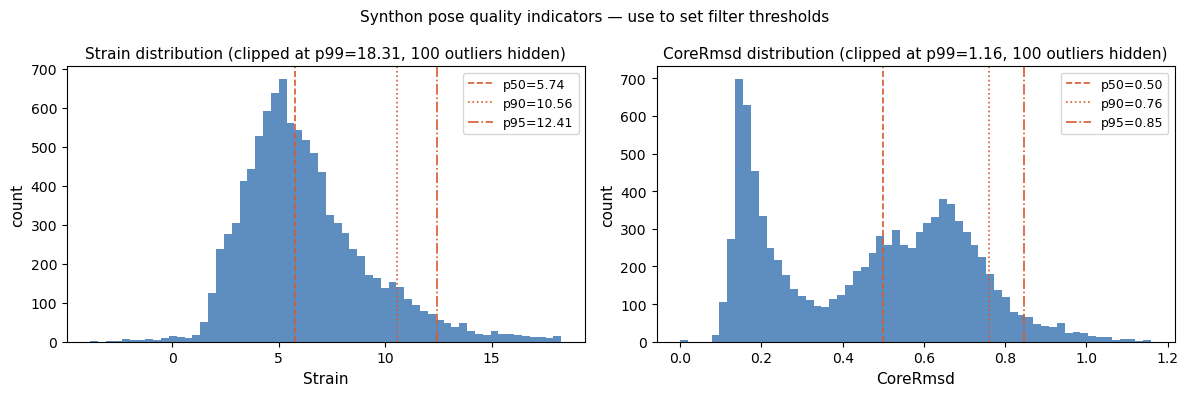


[DONE] Distribution plot saved → strain_corermsd_distributions.png


In [133]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ── Define column groups ───────────────────────────────────────────────────────
SYNTHON_SCORE_COLS    = ["SubstScore", "RTCNN_Score",'DockScore',]   # meaningful proxy scores
FULL_LIGAND_COLS      = ["FullLigand_Score", "FullLigand_RTCNNscore"]
QUALITY_FILTER_COLS   = ["Strain", "CoreRmsd"]                       # pose quality indicators

# Force numeric
for col in SYNTHON_SCORE_COLS + FULL_LIGAND_COLS + QUALITY_FILTER_COLS:
    df_joined[col] = pd.to_numeric(df_joined[col], errors="coerce")

df_work = df_joined.copy()

# ══════════════════════════════════════════════════════════════════════════════
# PART 1 — Full correlation (all 4802 pairs, no filtering)
# ══════════════════════════════════════════════════════════════════════════════
print(f"{'='*65}")
print(f"PART 1 — Correlation on full dataset (n={len(df_work)})")
print(f"{'='*65}")

corr_rows = []
for proxy in SYNTHON_SCORE_COLS:
    for target in FULL_LIGAND_COLS:
        sub = df_work[[proxy, target]].dropna()
        if len(sub) < 5:
            continue
        sr, sp = stats.spearmanr(sub[proxy], sub[target])
        pr, pp = stats.pearsonr(sub[proxy],  sub[target])
        corr_rows.append({
            "proxy": proxy, "target": target, "n": len(sub),
            "spearman_r": round(sr, 4), "spearman_p": round(sp, 4),
            "pearson_r":  round(pr, 4), "pearson_p":  round(pp, 4),
        })

df_corr_full = pd.DataFrame(corr_rows).sort_values(["target", "spearman_r"])
print(df_corr_full.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# PART 2 — Distribution of Strain and CoreRmsd (to decide filter thresholds)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print(f"PART 2 — Strain and CoreRmsd distributions")
print(f"{'='*65}")

for col in QUALITY_FILTER_COLS:
    vals = df_work[col].dropna()
    print(f"\n{col} (n={len(vals)}):")
    print(f"  min={vals.min():.3f}  median={vals.median():.3f}  "
          f"mean={vals.mean():.3f}  max={vals.max():.3f}")
    for p in [25, 50, 75, 90, 95]:
        print(f"  p{p:2d} = {np.percentile(vals, p):.3f}")

# Plot distributions clipped at p99 to avoid outlier distortion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, QUALITY_FILTER_COLS):
    vals     = df_work[col].dropna()
    p99      = np.percentile(vals, 99)
    vals_clipped = vals[vals <= p99]     # clip at p99 for display only — stats above are unaffected

    n_outliers = len(vals) - len(vals_clipped)
    ax.hist(vals_clipped, bins=60, color="#185FA5", alpha=0.7, edgecolor="none")

    for p, ls in [(50, "--"), (90, ":"), (95, "-.")]:
        pval = np.percentile(vals, p)    # percentiles computed on full data
        ax.axvline(pval, linestyle=ls, color="#D85A30", linewidth=1.2,
                   label=f"p{p}={pval:.2f}")

    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("count", fontsize=11)
    ax.set_title(f"{col} distribution (clipped at p99={p99:.2f}, {n_outliers} outliers hidden)",
                 fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle("Synthon pose quality indicators — use to set filter thresholds", fontsize=11)
plt.tight_layout()
plt.savefig("strain_corermsd_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[DONE] Distribution plot saved → strain_corermsd_distributions.png")

After quality filter: 3682/9913 synthons retained (37.1%)
After docking cutoff (Score <= -25.0): 348 pairs retained
  (9.5% of pose-filtered set)


Correlation comparison across subsets

  Target: FullLigand_Score
  -----------------------------------------------------------------
                              subset       proxy    n  spearman_r  pearson_r
                 unfiltered (n=9913)  SubstScore 9913     -0.0872     0.0158
                 unfiltered (n=9913) RTCNN_Score 9913      0.1669     0.1572
                 unfiltered (n=9913)   DockScore 9913      0.1645     0.0030
              pose-filtered (n=3682)  SubstScore 3682     -0.2752    -0.1502
              pose-filtered (n=3682) RTCNN_Score 3682      0.1365     0.1344
              pose-filtered (n=3682)   DockScore 3682      0.0002    -0.0284
pose-filtered + Score<=-25.0 (n=348)  SubstScore  348     -0.0208     0.0164
pose-filtered + Score<=-25.0 (n=348) RTCNN_Score  348      0.2351     0.2668
pose-filtered + Score<=-2

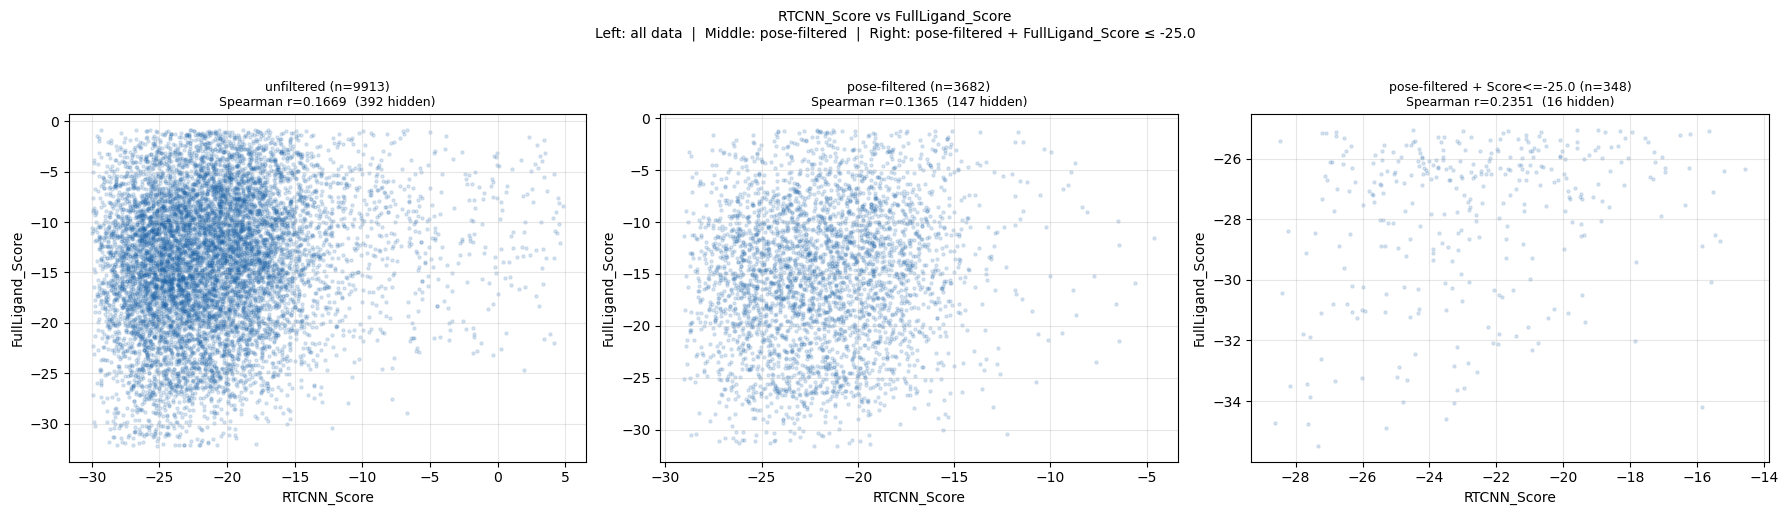


[DONE] Saved → correlation_three_subsets.png


In [134]:
# ── Apply pose quality filter ──────────────────────────────────────────────────
STRAIN_MAX        = 15.0
CORERMSD_MAX      = 2.0
DOCKING_CUTOFF    = -25.0    # only keep pairs where full ligand docked well

mask = (df_work["Strain"] <= STRAIN_MAX) & (df_work["CoreRmsd"] <= CORERMSD_MAX)
df_filtered = df_work[mask]
print(f"After quality filter: {len(df_filtered)}/{len(df_work)} synthons retained "
      f"({100*len(df_filtered)/len(df_work):.1f}%)")

# ── Restrict to full ligands with FullLigand_Score <= cutoff ──────────────────
df_top = df_filtered[df_filtered["FullLigand_Score"] <= DOCKING_CUTOFF]
print(f"After docking cutoff (Score <= {DOCKING_CUTOFF}): {len(df_top)} pairs retained")
print(f"  ({100*len(df_top)/len(df_filtered):.1f}% of pose-filtered set)\n")

# ══════════════════════════════════════════════════════════════════════════════
# Correlation — three subsets side by side
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print(f"Correlation comparison across subsets")
print(f"{'='*70}")

subsets = {
    f"unfiltered (n={len(df_work)})":                              df_work,
    f"pose-filtered (n={len(df_filtered)})":                       df_filtered,
    f"pose-filtered + Score<={DOCKING_CUTOFF} (n={len(df_top)})":  df_top,
}

corr_rows = []
for subset_label, df_sub in subsets.items():
    for proxy in SYNTHON_SCORE_COLS:
        for target in FULL_LIGAND_COLS:
            sub = df_sub[[proxy, target]].dropna()
            if len(sub) < 5:
                continue
            sr, sp = stats.spearmanr(sub[proxy], sub[target])
            pr, pp = stats.pearsonr(sub[proxy],  sub[target])
            corr_rows.append({
                "subset":     subset_label,
                "proxy":      proxy,
                "target":     target,
                "n":          len(sub),
                "spearman_r": round(sr, 4),
                "spearman_p": round(sp, 4),
                "pearson_r":  round(pr, 4),
            })

df_corr_all = pd.DataFrame(corr_rows)

for target in FULL_LIGAND_COLS:
    print(f"\n  Target: {target}")
    print(f"  {'-'*65}")
    sub = df_corr_all[df_corr_all["target"] == target]
    print(sub[["subset", "proxy", "n", "spearman_r", "pearson_r"]].to_string(index=False))

# ── Scatter plots: three subsets for best proxy ───────────────────────────────
best_proxy = "RTCNN_Score"
target     = "FullLigand_Score"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, df_plot) in zip(axes, subsets.items()):
    sub = df_plot[[best_proxy, target]].dropna()
    if len(sub) < 5:
        ax.set_visible(False)
        continue

    sr, _ = stats.spearmanr(sub[best_proxy], sub[target])

    # Clip at p1/p99 for display only — stats computed on full sub
    x_min = np.percentile(sub[best_proxy], 1)
    x_max = np.percentile(sub[best_proxy], 99)
    y_min = np.percentile(sub[target], 1)
    y_max = np.percentile(sub[target], 99)
    sub_display = sub[
        (sub[best_proxy] >= x_min) & (sub[best_proxy] <= x_max) &
        (sub[target]     >= y_min) & (sub[target]     <= y_max)
    ]
    n_hidden = len(sub) - len(sub_display)

    ax.scatter(sub_display[best_proxy], sub_display[target],
               alpha=0.15, s=5, color="#185FA5")
    ax.set_xlabel(best_proxy, fontsize=10)
    ax.set_ylabel(target, fontsize=10)
    ax.set_title(f"{label}\nSpearman r={sr:.4f}  ({n_hidden} hidden)", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"{best_proxy} vs {target}\n"
    f"Left: all data  |  Middle: pose-filtered  |  "
    f"Right: pose-filtered + FullLigand_Score ≤ {DOCKING_CUTOFF}",
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig("correlation_three_subsets.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[DONE] Saved → correlation_three_subsets.png")

Enrichment analysis on 3682 synthon-ligand pairs

Proxy: SubstScore
  Top-1% ground truth (36 compounds)  [higher=better]:
    retain top-10% → recall=0.167  random=0.100  EF=1.67x
    retain top-20% → recall=0.361  random=0.200  EF=1.81x
    retain top-30% → recall=0.667  random=0.300  EF=2.22x
    retain top-50% → recall=0.972  random=0.500  EF=1.94x

  Top-5% ground truth (184 compounds)  [higher=better]:
    retain top-10% → recall=0.174  random=0.100  EF=1.74x
    retain top-20% → recall=0.386  random=0.200  EF=1.93x
    retain top-30% → recall=0.592  random=0.300  EF=1.97x
    retain top-50% → recall=0.875  random=0.500  EF=1.75x

  Top-10% ground truth (368 compounds)  [higher=better]:
    retain top-10% → recall=0.198  random=0.100  EF=1.98x
    retain top-20% → recall=0.399  random=0.200  EF=2.00x
    retain top-30% → recall=0.565  random=0.300  EF=1.88x
    retain top-50% → recall=0.826  random=0.500  EF=1.65x

  Top-20% ground truth (736 compounds)  [higher=better]:
    reta

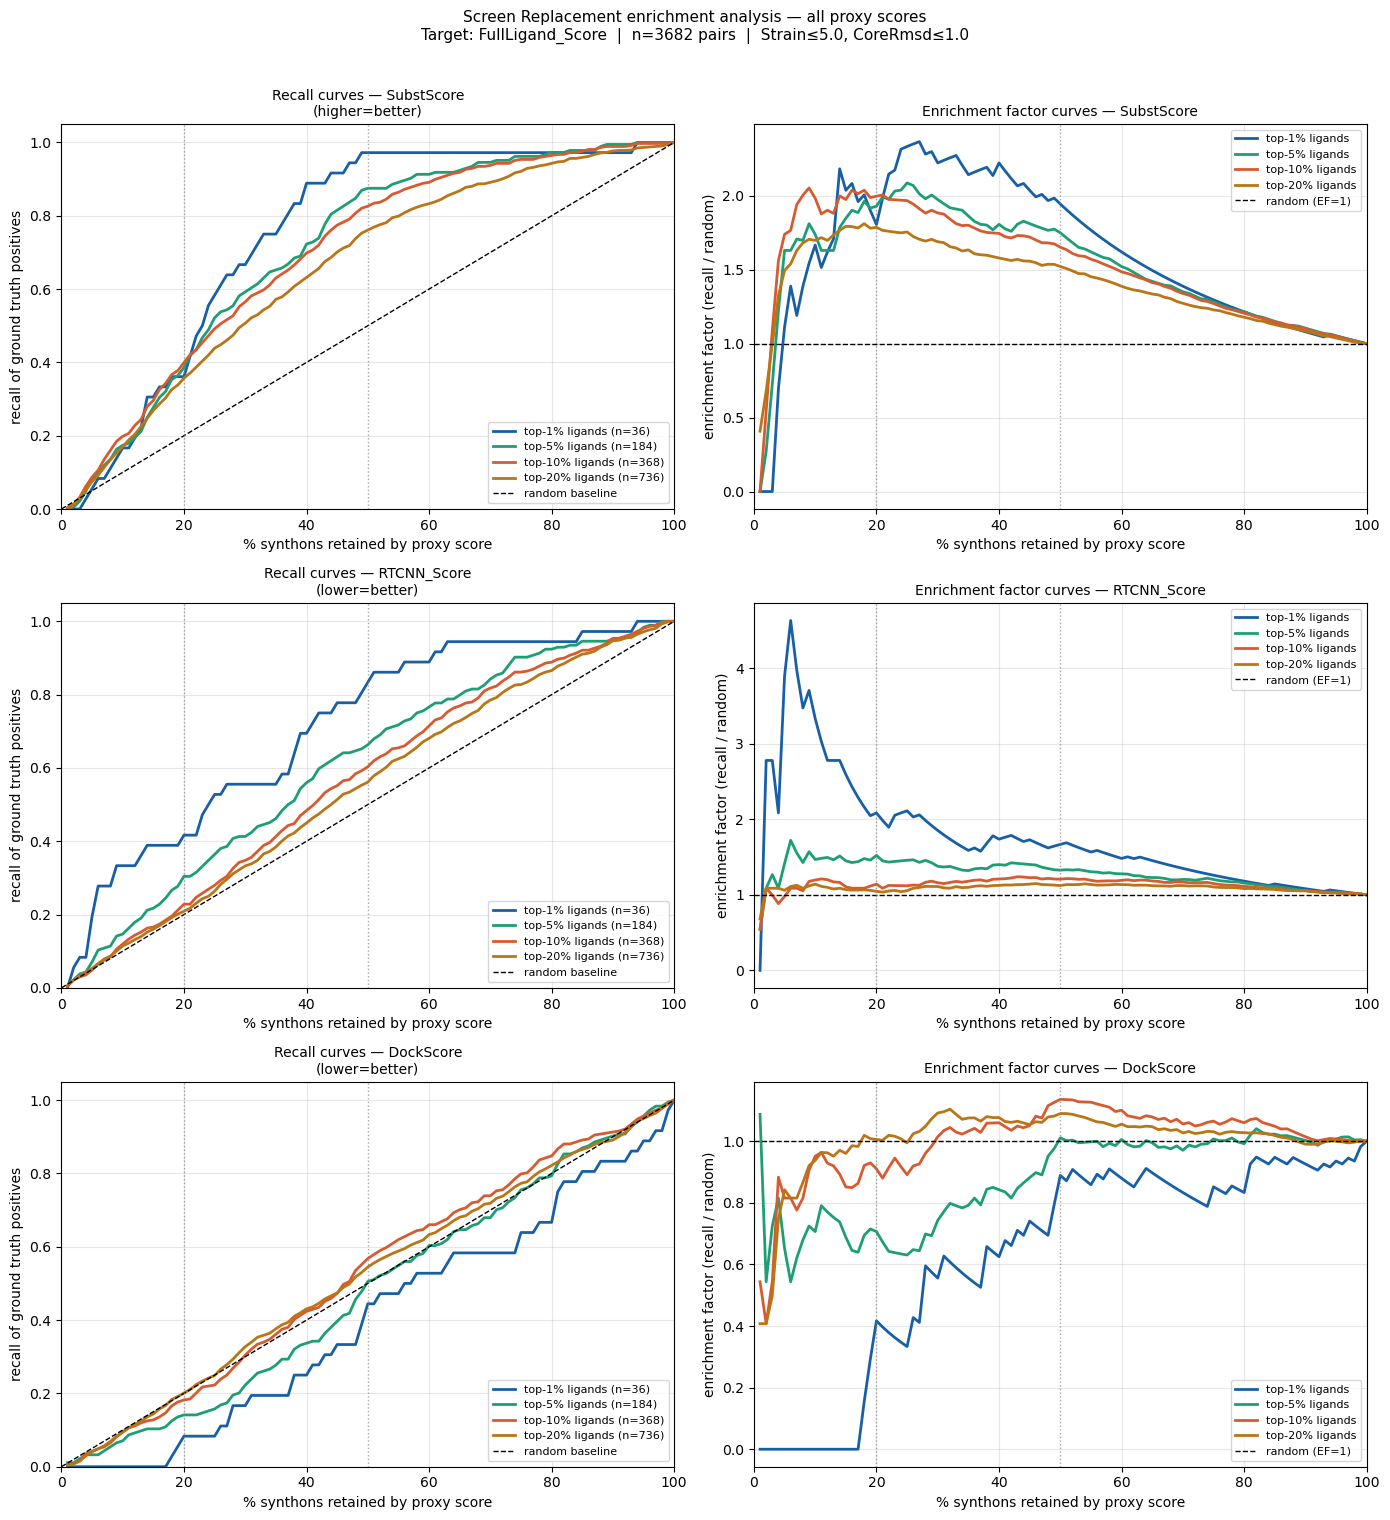

[DONE] Saved → enrichment_analysis_all_proxies.png


In [135]:
import numpy as np
import matplotlib.pyplot as plt

# ── Configuration ──────────────────────────────────────────────────────────────
PROXY_COLS   = ["SubstScore", "RTCNN_Score", "DockScore"]
TARGET_COL   = "FullLigand_Score"
Y_THRESHOLDS = [1, 5, 10, 20]
X_RANGE      = np.linspace(1, 100, 100)
y_colors     = ["#185FA5", "#1D9E75", "#D85A30", "#BA7517"]

df_enrich = df_filtered[PROXY_COLS + [TARGET_COL, "full_ligand_inchikey"]].dropna()
n_total   = len(df_enrich)
print(f"Enrichment analysis on {n_total} synthon-ligand pairs\n")

# ── One row per proxy, two panels (recall + EF) per row ───────────────────────
fig, axes = plt.subplots(len(PROXY_COLS), 2,
                         figsize=(14, 5 * len(PROXY_COLS)))

for row_idx, proxy_col in enumerate(PROXY_COLS):
    ax_recall = axes[row_idx, 0]
    ax_ef     = axes[row_idx, 1]

    print(f"{'='*60}")
    print(f"Proxy: {proxy_col}")
    print(f"{'='*60}")

    for y_pct, color in zip(Y_THRESHOLDS, y_colors):
        n_positives   = max(1, int(np.floor(n_total * y_pct / 100)))
        top_y_ligands = set(
            df_enrich.nsmallest(n_positives, TARGET_COL)["full_ligand_inchikey"].tolist()
        )

        # Determine ranking direction: lower or higher = better for this proxy
        median    = df_enrich[proxy_col].median()
        low_mean  = df_enrich[df_enrich[proxy_col] <= median][TARGET_COL].mean()
        high_mean = df_enrich[df_enrich[proxy_col] >  median][TARGET_COL].mean()
        lower_is_better = low_mean < high_mean

        recalls, efs = [], []
        for x_pct in X_RANGE:
            n_keep    = max(1, int(np.floor(n_total * x_pct / 100)))
            top_x_syn = set(
                (df_enrich.nsmallest(n_keep, proxy_col) if lower_is_better
                 else df_enrich.nlargest(n_keep, proxy_col))
                ["full_ligand_inchikey"].tolist()
            )
            recall = len(top_y_ligands & top_x_syn) / len(top_y_ligands)
            ef     = recall / (x_pct / 100)
            recalls.append(recall)
            efs.append(ef)

        # Print checkpoints
        print(f"  Top-{y_pct}% ground truth ({n_positives} compounds)  "
              f"[{'lower' if lower_is_better else 'higher'}=better]:")
        for checkpoint in [10, 20, 30, 50]:
            idx    = np.searchsorted(X_RANGE, checkpoint)
            r      = recalls[min(idx, len(recalls)-1)]
            print(f"    retain top-{checkpoint}% → recall={r:.3f}  "
                  f"random={checkpoint/100:.3f}  EF={r/(checkpoint/100):.2f}x")
        print()

        ax_recall.plot(X_RANGE, recalls, color=color, linewidth=2,
                       label=f"top-{y_pct}% ligands (n={n_positives})")
        ax_ef.plot(X_RANGE, efs, color=color, linewidth=2,
                   label=f"top-{y_pct}% ligands")

    # Format recall panel
    ax_recall.plot([0, 100], [0, 1], "k--", linewidth=1, label="random baseline")
    ax_recall.axvline(20, color="gray", linestyle=":", linewidth=1, alpha=0.7)
    ax_recall.axvline(50, color="gray", linestyle=":", linewidth=1, alpha=0.7)
    ax_recall.set_xlabel("% synthons retained by proxy score", fontsize=10)
    ax_recall.set_ylabel("recall of ground truth positives", fontsize=10)
    ax_recall.set_title(f"Recall curves — {proxy_col}\n"
                        f"({'lower' if lower_is_better else 'higher'}=better)", fontsize=10)
    ax_recall.legend(fontsize=8)
    ax_recall.set_xlim(0, 100)
    ax_recall.set_ylim(0, 1.05)
    ax_recall.grid(True, alpha=0.3)

    # Format EF panel
    ax_ef.axhline(1.0, color="k", linestyle="--", linewidth=1, label="random (EF=1)")
    ax_ef.axvline(20, color="gray", linestyle=":", linewidth=1, alpha=0.7)
    ax_ef.axvline(50, color="gray", linestyle=":", linewidth=1, alpha=0.7)
    ax_ef.set_xlabel("% synthons retained by proxy score", fontsize=10)
    ax_ef.set_ylabel("enrichment factor (recall / random)", fontsize=10)
    ax_ef.set_title(f"Enrichment factor curves — {proxy_col}", fontsize=10)
    ax_ef.legend(fontsize=8)
    ax_ef.set_xlim(0, 100)
    ax_ef.grid(True, alpha=0.3)

plt.suptitle(
    f"Screen Replacement enrichment analysis — all proxy scores\n"
    f"Target: {TARGET_COL}  |  n={n_total} pairs  |  "
    f"Strain≤{STRAIN_MAX}, CoreRmsd≤{CORERMSD_MAX}",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig("enrichment_analysis_all_proxies.png", dpi=150, bbox_inches="tight")
plt.show()
print("[DONE] Saved → enrichment_analysis_all_proxies.png")

Score distribution comparison on 3682 pairs



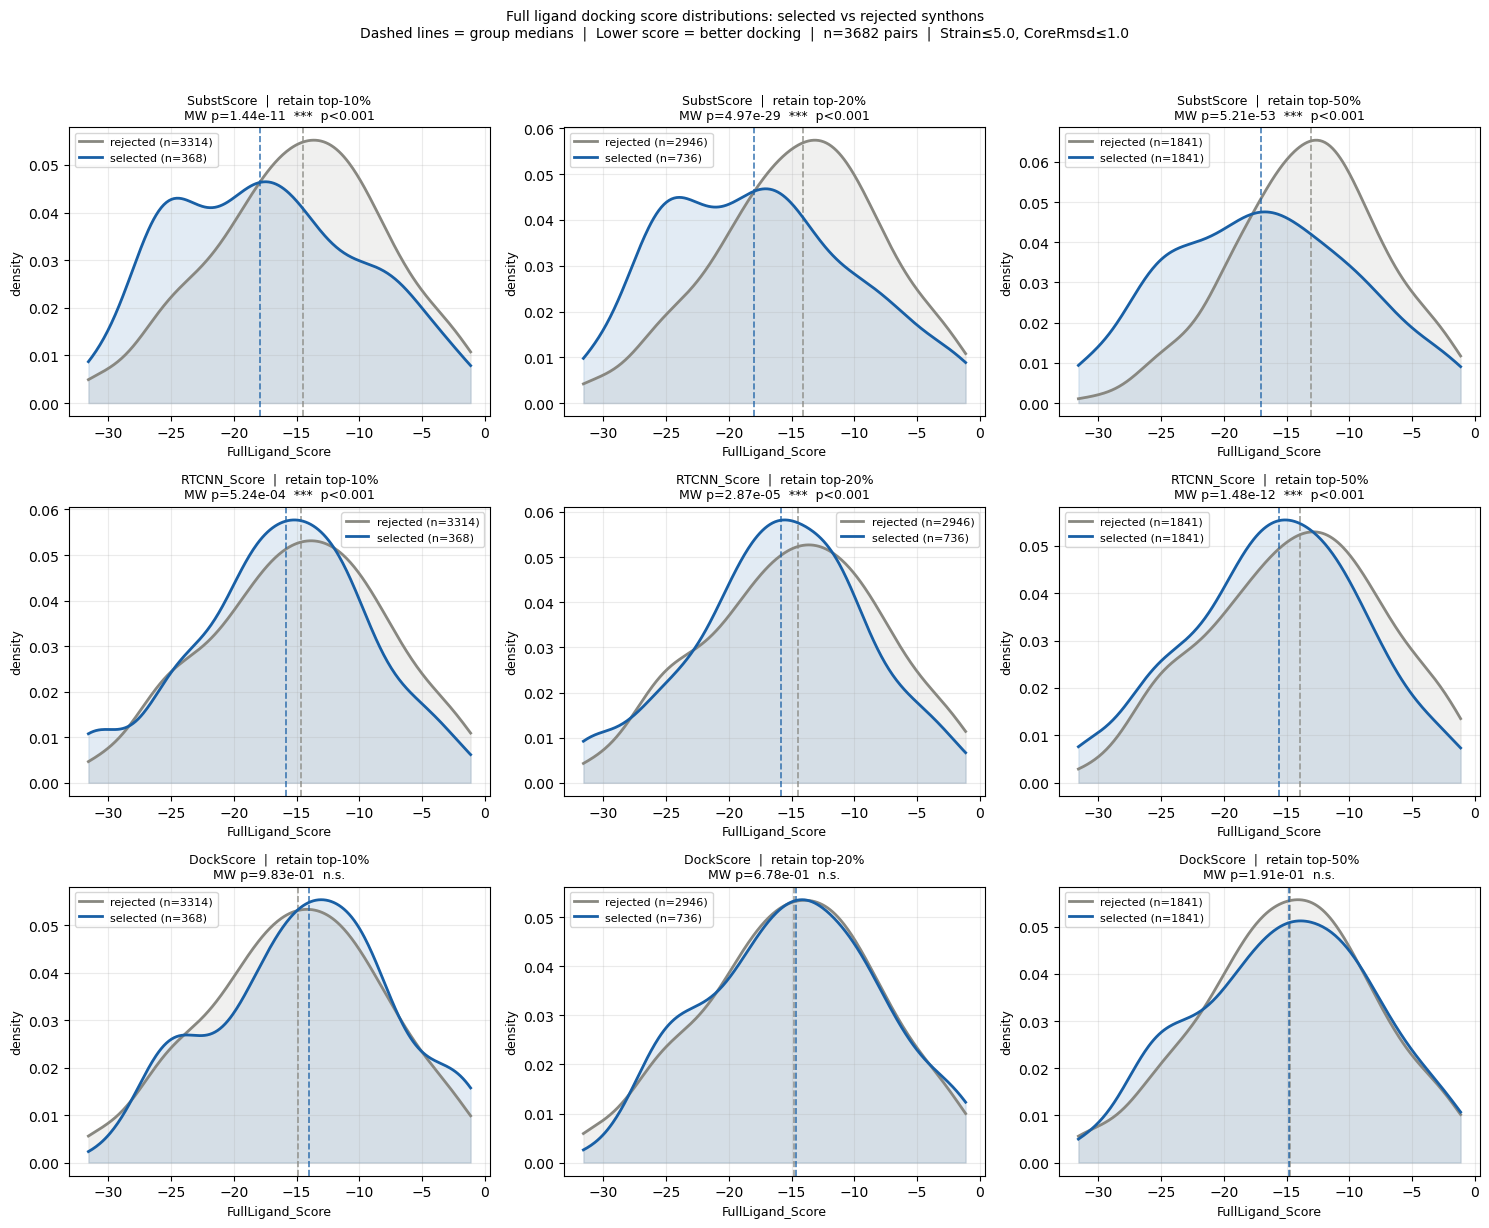


SUMMARY — Selected vs Rejected score distributions
(delta_median = selected - rejected, negative = selected scores better)

      proxy  retain_X%  median_selected  median_rejected  delta_median  mean_selected  mean_rejected     MW_p  significant
 SubstScore         10          -17.881          -14.513        -3.368        -17.410        -14.821 0.000000         True
 SubstScore         20          -17.986          -14.082        -3.904        -17.665        -14.434 0.000000         True
 SubstScore         50          -17.018          -13.084        -3.934        -16.885        -13.274 0.000000         True
RTCNN_Score         10          -15.821          -14.652        -1.169        -16.351        -14.938 0.000524         True
RTCNN_Score         20          -15.820          -14.514        -1.307        -16.075        -14.831 0.000029         True
RTCNN_Score         50          -15.590          -13.927        -1.663        -15.934        -14.225 0.000000         True
  DockScore   

In [136]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ── Configuration ──────────────────────────────────────────────────────────────
PROXY_COLS    = ["SubstScore", "RTCNN_Score", "DockScore"]
TARGET_COL    = "FullLigand_Score"
X_CHECKPOINTS = [10, 20, 50]    # synthon retention % to compare

df_dist = df_filtered[PROXY_COLS + [TARGET_COL, "full_ligand_inchikey"]].dropna()
n_total = len(df_dist)
print(f"Score distribution comparison on {n_total} pairs\n")

# ── One row per proxy, one column per retention threshold ──────────────────────
fig, axes = plt.subplots(len(PROXY_COLS), len(X_CHECKPOINTS),
                         figsize=(5 * len(X_CHECKPOINTS), 4 * len(PROXY_COLS)))

summary_rows = []

for row_idx, proxy_col in enumerate(PROXY_COLS):

    # Determine ranking direction
    median          = df_dist[proxy_col].median()
    lower_is_better = (df_dist[df_dist[proxy_col] <= median][TARGET_COL].mean()
                       < df_dist[df_dist[proxy_col] > median][TARGET_COL].mean())

    for col_idx, x_pct in enumerate(X_CHECKPOINTS):
        ax = axes[row_idx, col_idx]

        # Split into selected vs rejected by proxy score
        n_keep = max(1, int(np.floor(n_total * x_pct / 100)))
        if lower_is_better:
            selected_idx = df_dist.nsmallest(n_keep, proxy_col).index
        else:
            selected_idx = df_dist.nlargest(n_keep, proxy_col).index

        scores_selected = df_dist.loc[selected_idx,   TARGET_COL].dropna()
        scores_rejected = df_dist.loc[~df_dist.index.isin(selected_idx), TARGET_COL].dropna()

        # Mann-Whitney U test: is selected group significantly better?
        u_stat, p_val = stats.mannwhitneyu(
            scores_selected, scores_rejected, alternative="less"  # selected < rejected = better
        )

        # KDE curves clipped at p1/p99 of full data to avoid tail distortion
        x_min = np.percentile(df_dist[TARGET_COL], 1)
        x_max = np.percentile(df_dist[TARGET_COL], 99)
        x_grid = np.linspace(x_min, x_max, 300)

        for scores, color, label in [
            (scores_rejected, "#888780", f"rejected (n={len(scores_rejected)})"),
            (scores_selected, "#185FA5", f"selected (n={len(scores_selected)})"),
        ]:
            kde  = gaussian_kde(scores.clip(x_min, x_max), bw_method=0.3)
            ax.plot(x_grid, kde(x_grid), color=color, linewidth=2, label=label)
            ax.axvline(scores.median(), color=color, linestyle="--",
                       linewidth=1.2, alpha=0.8)
            ax.fill_between(x_grid, kde(x_grid), alpha=0.12, color=color)

        # Significance label
        if p_val < 0.001:
            sig_label = "***  p<0.001"
        elif p_val < 0.01:
            sig_label = "**   p<0.01"
        elif p_val < 0.05:
            sig_label = "*    p<0.05"
        else:
            sig_label = "n.s."

        ax.set_xlabel(TARGET_COL, fontsize=9)
        ax.set_ylabel("density", fontsize=9)
        ax.set_title(f"{proxy_col}  |  retain top-{x_pct}%\n"
                     f"MW p={p_val:.2e}  {sig_label}", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)

        # Collect summary stats
        summary_rows.append({
            "proxy":              proxy_col,
            "retain_X%":          x_pct,
            "n_selected":         len(scores_selected),
            "n_rejected":         len(scores_rejected),
            "median_selected":    round(scores_selected.median(), 3),
            "median_rejected":    round(scores_rejected.median(), 3),
            "mean_selected":      round(scores_selected.mean(), 3),
            "mean_rejected":      round(scores_rejected.mean(), 3),
            "delta_median":       round(scores_selected.median() - scores_rejected.median(), 3),
            "MW_U":               round(u_stat, 1),
            "MW_p":               round(p_val, 6),
            "significant":        p_val < 0.05,
        })

plt.suptitle(
    f"Full ligand docking score distributions: selected vs rejected synthons\n"
    f"Dashed lines = group medians  |  Lower score = better docking  |  "
    f"n={n_total} pairs  |  Strain≤{STRAIN_MAX}, CoreRmsd≤{CORERMSD_MAX}",
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig("score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print summary table ────────────────────────────────────────────────────────
df_summary = pd.DataFrame(summary_rows)
print(f"\n{'='*75}")
print("SUMMARY — Selected vs Rejected score distributions")
print(f"{'='*75}")
print("(delta_median = selected - rejected, negative = selected scores better)\n")
print(df_summary[[
    "proxy", "retain_X%",
    "median_selected", "median_rejected", "delta_median",
    "mean_selected",   "mean_rejected",
    "MW_p", "significant"
]].to_string(index=False))
print("\n[DONE] Saved → score_distributions.png")